Goal of the project: 

Your company works in road traffic management and risk prevention, and asked you to create an updated dashboard of the best Italian municipalities to invest into. After discussing with the business, you decide that you need to know what are the places with the highest ratio of car accidents in the latest years, with an option for forecasting. The data at our current disposal is unreliable, outdated and too dirty to work with.

The goal: being able to see what towns have the highest accidents rates, total accidents, population and any other statistic that might be meaningful to our business goal! E.g.: what are the best cities to invest into? Why?

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
# Loading the file 
car_accidents_df = pd.read_csv('C:/Users/andre/OneDrive/Desktop/Boolean/Final Project/car_accidents.csv')

C:\Users\andre\AppData\Local\Temp\ipykernel_39524\780528760.py:2: DtypeWarning: Columns (0: Comune (dizione straniera)) have mixed types. Specify dtype option on import or set low_memory=False.
  car_accidents_df = pd.read_csv('C:/Users/andre/OneDrive/Desktop/Boolean/Final Project/car_accidents.csv')


In [194]:
car_accidents_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      573552 non-null  int64  
 1   REF_AREA                        573552 non-null  int64  
 2   DATA_TYPE                       573552 non-null  str    
 3   RESULT                          573552 non-null  str    
 4   TIME_PERIOD                     573552 non-null  int64  
 5   OBS_VALUE                       573552 non-null  int64  
 6   Codice Ripartizione geografica  548685 non-null  float64
 7   Codice Regione                  548685 non-null  float64
 8   Codice Provincia (Storico)      548685 non-null  float64
 9   Codice Provincia/Uts            548685 non-null  float64
 10  Codice Comune (alfanumerico)    548685 non-null  float64
 11  Codice Comune (numerico)        548685 non-null  float64
 12  Comune                     

In [195]:
car_accidents_df = car_accidents_df.drop(columns = ['Unnamed: 0'])

In [4]:
car_accidents_df

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),...,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1001,KILLINJ,F,2001,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
1,1001,KILLINJ,F,2002,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
2,1001,KILLINJ,F,2003,7,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
3,1001,KILLINJ,F,2004,13,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
4,1001,KILLINJ,F,2005,2,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573547,111107,ROADACC,9,2020,2,5.0,20.0,111.0,111.0,111107.0,...,NaN,SU,0.0,0.0,2407.0,2011.0,27.1937,2020.0,2549.0,2020.0
573548,111107,ROADACC,9,2021,5,5.0,20.0,111.0,111.0,111107.0,...,NaN,SU,0.0,0.0,2407.0,2011.0,27.1937,2020.0,2549.0,2020.0
573549,111107,ROADACC,9,2022,1,5.0,20.0,111.0,111.0,111107.0,...,NaN,SU,0.0,0.0,2407.0,2011.0,27.1937,2020.0,2549.0,2020.0
573550,111107,ROADACC,9,2023,4,5.0,20.0,111.0,111.0,111107.0,...,NaN,SU,0.0,0.0,2407.0,2011.0,27.1937,2020.0,2549.0,2020.0


In [7]:
# Lookig for NaN values
car_accidents_df['Comune'].isna().sum()

np.int64(24939)

In [8]:
car_accidents_df.shape

(573552, 23)

- There 573552 total rows, 24939 (4,35%) of these have 'Comune' column as NaN. I'll keep these NaN values for the first overall analysis and exclude them when I will analyze each Comune name

In [15]:
# Understanding how mani accidents per REF_AREA with Comune as NaN
car_accidents_df[car_accidents_df['Comune'].isna()].groupby(['REF_AREA', 'OBS_VALUE']).size().reset_index().sort_values(by=0, ascending=False)

,REF_AREA,OBS_VALUE,0
124,6064,0,55
5378,96062,0,54
5549,103030,0,54
41,1277,0,52
5445,97081,0,51
...,...,...,...
30,1168,19,1
24,1168,10,1
454,15017,25,1
451,15017,20,1


In [5]:
car_accidents_df.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),...,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1001,KILLINJ,F,2001,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
1,1001,KILLINJ,F,2002,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
2,1001,KILLINJ,F,2003,7,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
3,1001,KILLINJ,F,2004,13,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
4,1001,KILLINJ,F,2005,2,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0.0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0


Understanding the data: 

- DATA_TYPE has 'KILLINJ' OR 'ROADACC' VALUES: KILLINJ = Killed and injured - ROADACC = Road accidents

- RESULT has F, M OR 9 VALUES: F = Feriti, M = Morti, 9 = Accidents without injuries and deads

- OBS_VALUE = Num of observations

In [5]:
all_car_accidents = car_accidents_df.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

road_accidents = car_accidents_df[car_accidents_df['DATA_TYPE'] == 'ROADACC'].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

kill_or_inj = car_accidents_df[car_accidents_df['DATA_TYPE'] == 'KILLINJ'].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

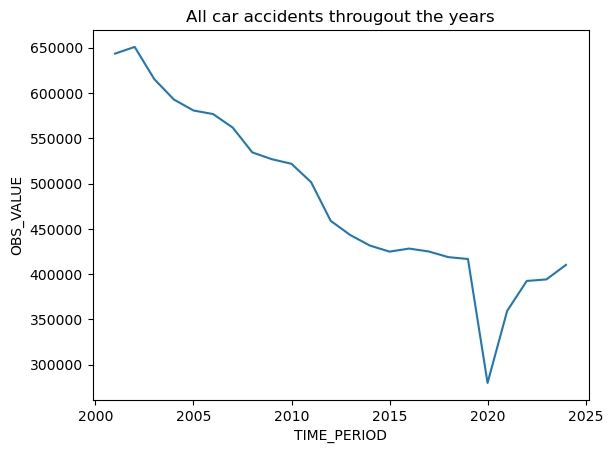

In [6]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = all_car_accidents)
plt.title('All car accidents througout the years')
plt.show()

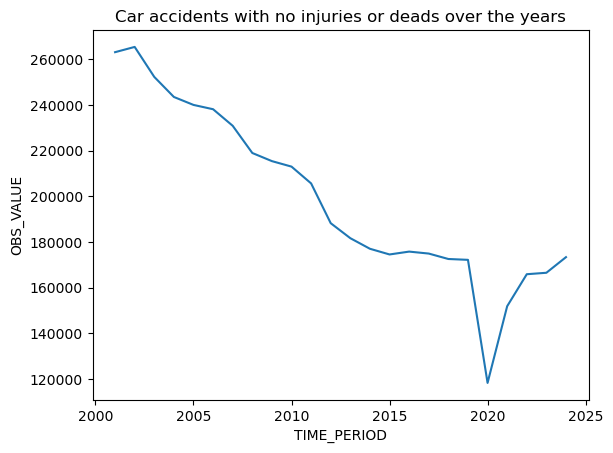

In [7]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = road_accidents)
plt.title('Car accidents with no injuries or deads over the years')
plt.show()

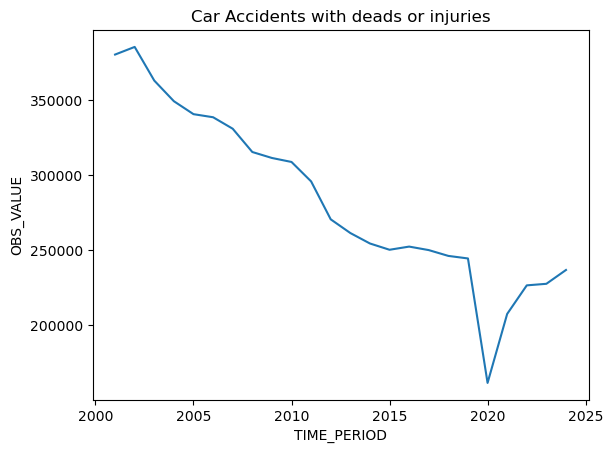

In [8]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = kill_or_inj)
plt.title('Car Accidents with deads or injuries')
plt.show()

In [10]:
injuries = car_accidents_df[(car_accidents_df['DATA_TYPE'] == 'KILLINJ') & (car_accidents_df['RESULT'] == 'F')].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

kills = car_accidents_df[(car_accidents_df['DATA_TYPE'] == 'KILLINJ') & (car_accidents_df['RESULT'] == 'M')].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

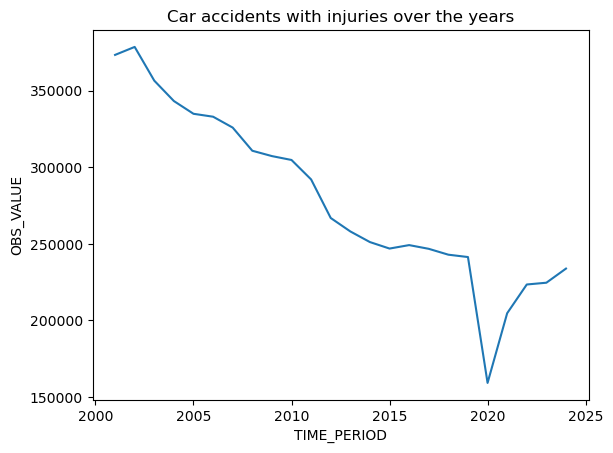

In [11]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = injuries)
plt.title('Car accidents with injuries over the years')
plt.show()

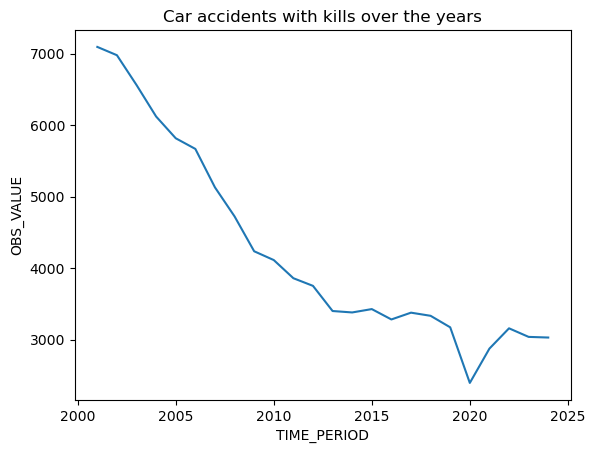

In [12]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = kills)
plt.title('Car accidents with kills over the years')
plt.show()

By Taking a look to all the type of car accidents, the same schema repropose:

- The rate of accidents decreased over the years reaching the lowest number in 2020 probably due to the Covid pandemia, in the last years the numbers increased by reaching the same number in the pre-Covid era but still a lot lower than in the early-2000s years. 


End of first part of analysis

In the second part I'll exclude Comune with NaN values


---------------------

In [13]:
# Excluding from the dataset data with no car accidents and Comune == NaN

car_accidents_filtered = car_accidents_df[car_accidents_df['OBS_VALUE'] > 0]
car_accidents_filtered = car_accidents_filtered[car_accidents_filtered['Comune'].notna()]

In [196]:
car_accidents_filtered.info()

<class 'pandas.DataFrame'>
Index: 331564 entries, 0 to 573551
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   REF_AREA                        331564 non-null  int64  
 1   DATA_TYPE                       331564 non-null  str    
 2   RESULT                          331564 non-null  str    
 3   TIME_PERIOD                     331564 non-null  int64  
 4   OBS_VALUE                       331564 non-null  int64  
 5   Codice Ripartizione geografica  331564 non-null  float64
 6   Codice Regione                  331564 non-null  float64
 7   Codice Provincia (Storico)      331564 non-null  float64
 8   Codice Provincia/Uts            331564 non-null  float64
 9   Codice Comune (alfanumerico)    331564 non-null  float64
 10  Codice Comune (numerico)        331564 non-null  float64
 11  Comune                          331564 non-null  str    
 12  Comune (dizione straniera)      

In [200]:
car_accidents_filtered.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),...,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1001,KILLINJ,F,2001,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
1,1001,KILLINJ,F,2002,10,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
2,1001,KILLINJ,F,2003,7,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
3,1001,KILLINJ,F,2004,13,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0
4,1001,KILLINJ,F,2005,2,1.0,1.0,1.0,201.0,1001.0,...,NaN,TO,0,0.0,2644.0,2011.0,13.1462,2020.0,2545.0,2020.0


In [ ]:
# Creating a function to transform float columns to integer

def float_to_int(series):
    if series.dtype == float:
        series = series.astype('int64')
    return series

In [ ]:
# Function application

car_accidents_filtered['Capoluogo di Provincia/Uts'] = float_to_int(car_accidents_filtered['Capoluogo di Provincia/Uts'])
car_accidents_filtered['Codice Ripartizione geografica'] = float_to_int(car_accidents_filtered['Codice Ripartizione geografica'])
car_accidents_filtered['Codice Regione'] = float_to_int(car_accidents_filtered['Codice Regione'])
car_accidents_filtered['Codice Provincia (Storico)'] = float_to_int(car_accidents_filtered['Codice Provincia (Storico)'])
car_accidents_filtered['Codice Provincia/Uts'] = float_to_int(car_accidents_filtered['Codice Provincia/Uts'])
car_accidents_filtered['Codice Comune (alfanumerico)'] = float_to_int(car_accidents_filtered['Codice Comune (alfanumerico)'])
car_accidents_filtered['Capoluogo di Regione'] = float_to_int(car_accidents_filtered['Capoluogo di Regione'])
car_accidents_filtered['Anno Censimento'] = float_to_int(car_accidents_filtered['Anno Censimento'])
car_accidents_filtered['Anno (Superficie)'] = float_to_int(car_accidents_filtered['Anno (Superficie)'])
car_accidents_filtered['Anno (Popolazione residente)'] = float_to_int(car_accidents_filtered['Anno (Popolazione residente)'])

In [205]:
car_accidents_filtered.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),...,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1001,KILLINJ,F,2001,10,1,1,1,201,1001,...,NaN,TO,0,0,2644.0,2011,13.1462,2020,2545.0,2020
1,1001,KILLINJ,F,2002,10,1,1,1,201,1001,...,NaN,TO,0,0,2644.0,2011,13.1462,2020,2545.0,2020
2,1001,KILLINJ,F,2003,7,1,1,1,201,1001,...,NaN,TO,0,0,2644.0,2011,13.1462,2020,2545.0,2020
3,1001,KILLINJ,F,2004,13,1,1,1,201,1001,...,NaN,TO,0,0,2644.0,2011,13.1462,2020,2545.0,2020
4,1001,KILLINJ,F,2005,2,1,1,1,201,1001,...,NaN,TO,0,0,2644.0,2011,13.1462,2020,2545.0,2020


In [17]:
most_municipalities_car_accidents = car_accidents_filtered.groupby(['Comune', 'Popolazione legale', 'Superficie (Kmq)'])['OBS_VALUE'].sum().sort_values(ascending=False).reset_index()

In [18]:
most_municipalities_car_accidents

,Comune,Popolazione legale,Superficie (Kmq),OBS_VALUE
0,Roma,2617175.0,1287.3716,901300
1,Milano,1242123.0,181.6783,629964
2,Genova,586180.0,240.2876,231413
3,Torino,872367.0,130.0645,217874
4,Firenze,358079.0,102.3156,165301
...,...,...,...,...
7850,Castelletto Molina,184.0,3.0662,2
7851,Vallerotonda,1671.0,59.6558,2
7852,Marzio,303.0,1.8580,2
7853,Volpara,133.0,3.7730,2


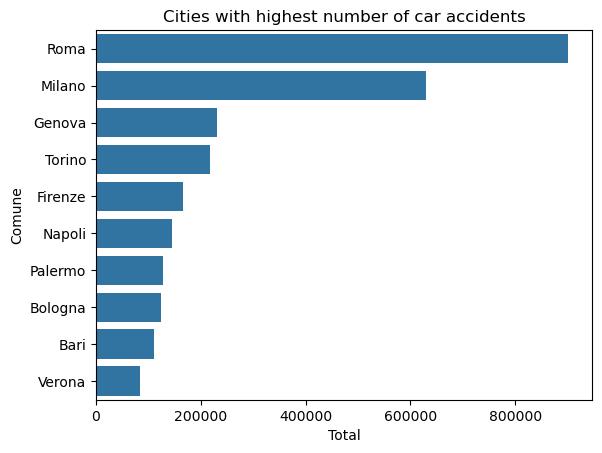

In [19]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = most_municipalities_car_accidents.head(10))
plt.xlabel('Total')
plt.title('Cities with highest number of car accidents')
plt.show()

In [23]:
most_muncipalities_serious_car_accidents = car_accidents_filtered[car_accidents_filtered['DATA_TYPE'] == 'KILLINJ'].groupby(['Comune', 'Popolazione legale', 'RESULT'])['OBS_VALUE'].sum().sort_values(ascending=False).reset_index()

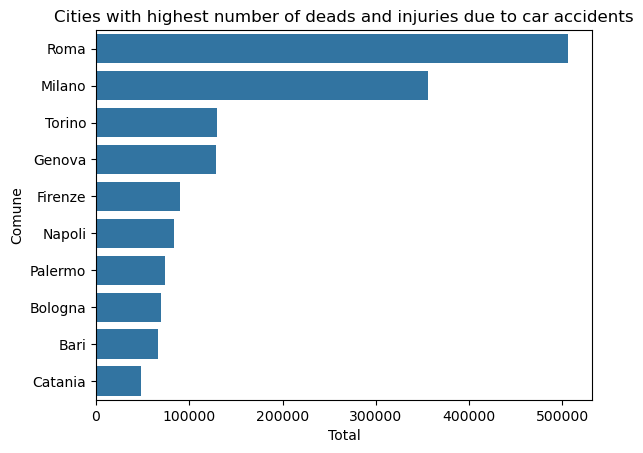

In [24]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = most_muncipalities_serious_car_accidents.head(10))
plt.xlabel('Total')
plt.title('Cities with highest number of deads and injuries due to car accidents')
plt.show()

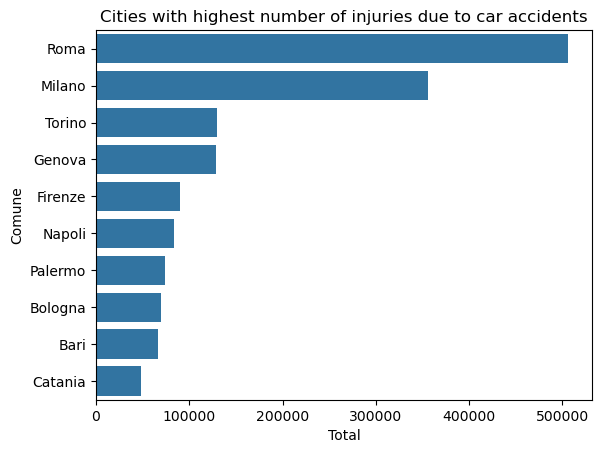

In [25]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = most_muncipalities_serious_car_accidents[most_muncipalities_serious_car_accidents['RESULT']=='F'].head(10))
plt.xlabel('Total')
plt.title('Cities with highest number of injuries due to car accidents')
plt.show()

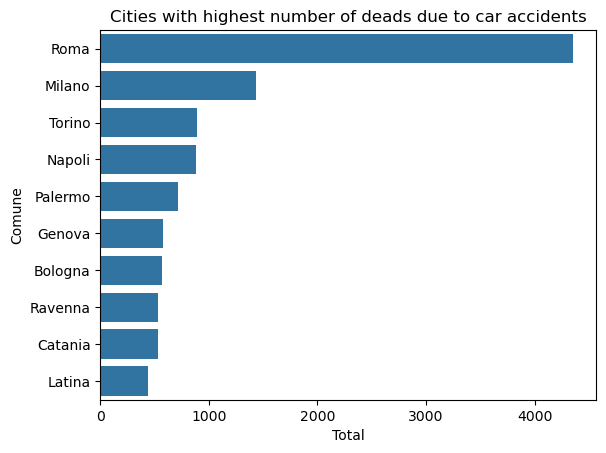

In [26]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = most_muncipalities_serious_car_accidents[most_muncipalities_serious_car_accidents['RESULT']=='M'].head(10))
plt.xlabel('Total')
plt.title('Cities with highest number of deads due to car accidents')
plt.show()

In [27]:
most_muncipalities_serious_car_accidents[most_muncipalities_serious_car_accidents['RESULT']=='M'].head(10)

,Comune,Popolazione legale,RESULT,OBS_VALUE
220,Roma,2617175.0,M,4350
700,Milano,1242123.0,M,1435
1096,Torino,872367.0,M,895
1110,Napoli,962003.0,M,881
1306,Palermo,657561.0,M,716
1568,Genova,586180.0,M,580
1597,Bologna,371337.0,M,565
1679,Ravenna,153740.0,M,531
1680,Catania,293902.0,M,530
1923,Latina,117892.0,M,442


Comments: 

- Roma and Milano are the cities with most car accidents and serious car accidents. In terms of deads Roma triplicates Milano. 

- Ravenna and latina despite not being in the top cities with car accidents, are in the top cities of deads caused by car accidents

In [29]:
most_municipalities_car_accidents['per_capita_accidents'] = round(most_municipalities_car_accidents['OBS_VALUE'] / most_municipalities_car_accidents['Popolazione legale'], 2)

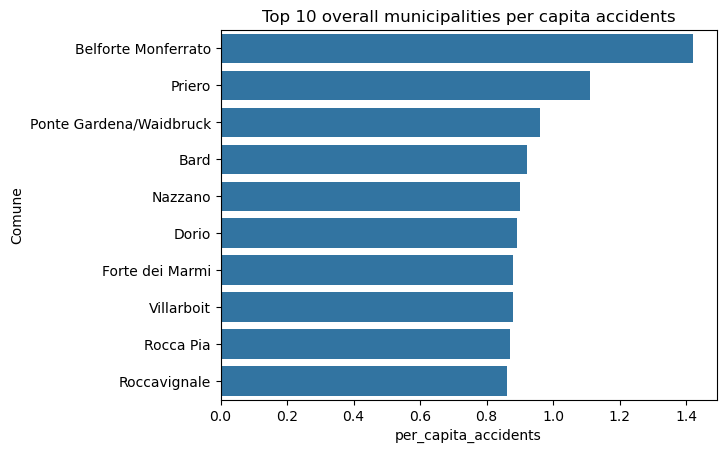

In [32]:
sns.barplot(x = 'per_capita_accidents', y = 'Comune', data = most_municipalities_car_accidents.sort_values(by = 'per_capita_accidents', ascending=False).head(10))
plt.title('Top 10 overall municipalities per capita accidents')
plt.show()

In [36]:
most_municipalities_car_accidents.sort_values(by = 'per_capita_accidents', ascending=False).head(10)

,Comune,Popolazione legale,Superficie (Kmq),OBS_VALUE,per_capita_accidents
1971,Belforte Monferrato,505.0,8.3258,715,1.42
2396,Priero,487.0,20.0092,542,1.11
4257,Ponte Gardena/Waidbruck,195.0,2.3282,187,0.96
5074,Bard,125.0,3.0315,115,0.92
1293,Nazzano,1361.0,12.3969,1223,0.90
3395,Dorio,337.0,11.6556,300,0.89
241,Forte dei Marmi,7660.0,9.1872,6766,0.88
2870,Villarboit,465.0,25.5109,409,0.88
4665,Rocca Pia,167.0,44.9610,146,0.87
2137,Roccavignale,746.0,17.7066,641,0.86


Comments: 

- By taking a look to the overall municipalities per_capita_accidents most of these municipality have a low number of habitants. However a more populated municipality as Forte dei Marmi comes out in the top 10. 

In the further analysis I will concetrate the data in the last years starting from 2019

----------------------

In [207]:
# Considering only last years data
car_accidents_recent_years = car_accidents_filtered[car_accidents_filtered['TIME_PERIOD'] >= 2019]

In [208]:
municipalities_per_incidents_recent_years = car_accidents_recent_years.groupby(['Comune', 'Popolazione legale', 'Superficie (Kmq)', 'DATA_TYPE', 'RESULT', 'Capoluogo di Provincia/Uts', 'Capoluogo di Regione'])['OBS_VALUE'].sum().sort_values(ascending=False).reset_index()

In [209]:
municipalities_per_incidents_recent_years

,Comune,Popolazione legale,Superficie (Kmq),DATA_TYPE,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE
0,Roma,2617175.0,1287.3716,KILLINJ,F,1,1,90070
1,Roma,2617175.0,1287.3716,ROADACC,9,1,1,71551
2,Milano,1242123.0,181.6783,KILLINJ,F,1,1,55223
3,Milano,1242123.0,181.6783,ROADACC,9,1,1,43922
4,Genova,586180.0,240.2876,KILLINJ,F,1,1,25913
...,...,...,...,...,...,...,...,...
19242,Stilo,2687.0,78.1081,KILLINJ,M,0,0,1
19243,Stigliano,4685.0,211.1428,KILLINJ,M,0,0,1
19244,Castel del Piano,4671.0,67.7697,KILLINJ,M,0,0,1
19245,Cardito,22322.0,3.1983,KILLINJ,M,0,0,1


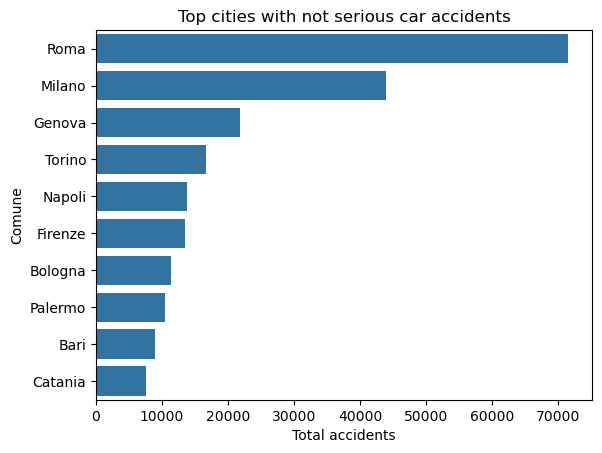

In [213]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = municipalities_per_incidents_recent_years[municipalities_per_incidents_recent_years['DATA_TYPE'] == 'ROADACC'].head(10))
plt.title('Top cities with not serious car accidents')
plt.xlabel('Total accidents')
plt.show()

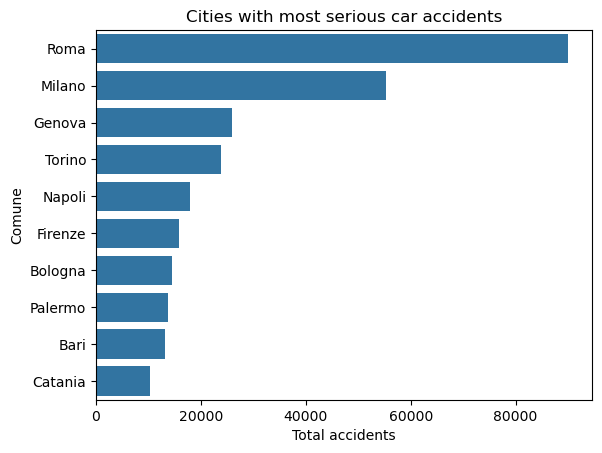

In [214]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = municipalities_per_incidents_recent_years[municipalities_per_incidents_recent_years['DATA_TYPE'] == 'KILLINJ'].head(10))
plt.title('Cities with most serious car accidents')
plt.xlabel('Total accidents')
plt.show()

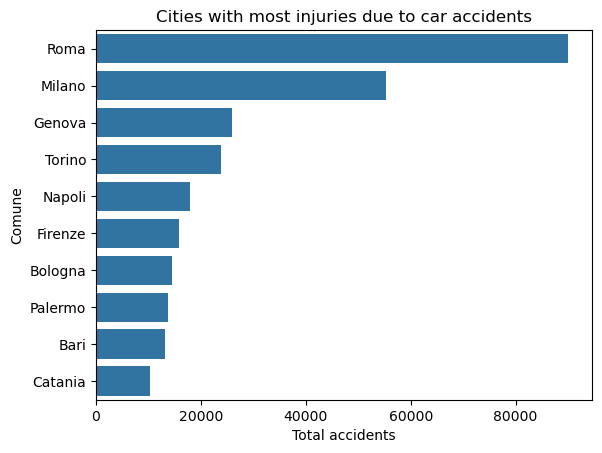

In [216]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = municipalities_per_incidents_recent_years[municipalities_per_incidents_recent_years['RESULT'] == 'F'].head(10))
plt.title('Cities with most injuries due to car accidents')
plt.xlabel('Total accidents')
plt.show()

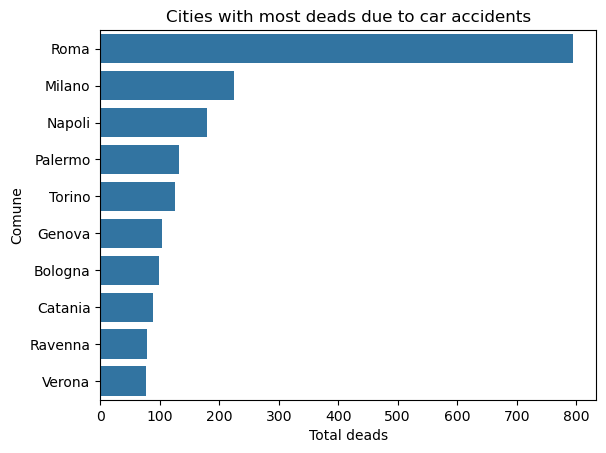

In [217]:
sns.barplot(x = 'OBS_VALUE', y = 'Comune', data = municipalities_per_incidents_recent_years[municipalities_per_incidents_recent_years['RESULT'] == 'M'].head(10))
plt.title('Cities with most deads due to car accidents')
plt.xlabel('Total deads')
plt.show()

In [112]:
municipalities_per_incidents_recent_years[municipalities_per_incidents_recent_years['RESULT'] == 'M'].head(10)

,Comune,Popolazione legale,Superficie (Kmq),DATA_TYPE,RESULT,OBS_VALUE
393,Roma,2617175.0,1287.3716,KILLINJ,M,794
1600,Milano,1242123.0,181.6783,KILLINJ,M,225
1956,Napoli,962003.0,118.9441,KILLINJ,M,179
2562,Palermo,657561.0,160.5878,KILLINJ,M,132
2694,Torino,872367.0,130.0645,KILLINJ,M,125
3168,Genova,586180.0,240.2876,KILLINJ,M,103
3284,Bologna,371337.0,140.8566,KILLINJ,M,99
3593,Catania,293902.0,182.7960,KILLINJ,M,88
3904,Ravenna,153740.0,653.8119,KILLINJ,M,79
3986,Verona,252520.0,198.9134,KILLINJ,M,77


The schema of recent years is pretty the same with the hystorical data: the top cities wtih serious and non serious car accidents are the same. In terms of deaths Roma quadruplicates Milano. 

In the following analysis I will concentrate only with serious car accidents.


-------------------

In [218]:
# Creating a df considering only serius car accidents
serious_car_accidents_per_comune_recent_years = car_accidents_filtered[car_accidents_filtered['DATA_TYPE'] == 'KILLINJ'].groupby(['Comune', 'TIME_PERIOD', 'Popolazione residente', 'Superficie (Kmq)', 'Codice Regione', 'RESULT', 'Capoluogo di Provincia/Uts', 'Capoluogo di Regione'])['OBS_VALUE'].sum().reset_index()
serious_car_accidents_per_comune_recent_years = serious_car_accidents_per_comune_recent_years[serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] >= 2019].reset_index()

In [219]:
# Addding per_capita_accidents, per_area_accidents and population_density variables

serious_car_accidents_per_comune_recent_years['per_capita_accidents'] = serious_car_accidents_per_comune_recent_years['OBS_VALUE'] / serious_car_accidents_per_comune_recent_years['Popolazione residente']
serious_car_accidents_per_comune_recent_years['per_area_accidents'] = serious_car_accidents_per_comune_recent_years['OBS_VALUE'] / serious_car_accidents_per_comune_recent_years['Superficie (Kmq)']
serious_car_accidents_per_comune_recent_years['population_density'] = serious_car_accidents_per_comune_recent_years['Popolazione residente'] / serious_car_accidents_per_comune_recent_years['Superficie (Kmq)']

In [221]:
serious_car_accidents_per_comune_recent_years.drop(columns='index')

,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
0,Abano Terme,2019,20095.0,21.4081,5,F,0,0,75,0.003732,3.503347,938.663403
1,Abano Terme,2019,20095.0,21.4081,5,M,0,0,1,0.000050,0.046711,938.663403
2,Abano Terme,2020,20095.0,21.4081,5,F,0,0,38,0.001891,1.775029,938.663403
3,Abano Terme,2021,20095.0,21.4081,5,F,0,0,55,0.002737,2.569121,938.663403
4,Abano Terme,2021,20095.0,21.4081,5,M,0,0,2,0.000100,0.093423,938.663403
...,...,...,...,...,...,...,...,...,...,...,...,...
46293,Zungri,2020,1854.0,23.4549,18,F,0,0,2,0.001079,0.085270,79.045317
46294,Zungri,2021,1854.0,23.4549,18,F,0,0,1,0.000539,0.042635,79.045317
46295,Zungri,2022,1854.0,23.4549,18,F,0,0,2,0.001079,0.085270,79.045317
46296,Zungri,2023,1854.0,23.4549,18,F,0,0,1,0.000539,0.042635,79.045317


In [150]:
serious_car_accidents_per_comune_recent_years.sort_values(by='per_capita_accidents', ascending=False).head(20)

,index,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
24074,97875,Moncenisio,2022,41.0,4.5007,1.0,F,0.0,0.0,5,0.121951,1.110938,9.109694
9988,40774,Castelmagno,2020,59.0,49.3070,1.0,M,0.0,0.0,5,0.084746,0.101405,1.196585
34593,140863,Salbertrand,2021,609.0,38.3198,1.0,F,0.0,0.0,50,0.082102,1.304808,15.892567
3010,12158,Balocco,2023,220.0,16.8079,1.0,F,0.0,0.0,18,0.081818,1.070925,13.089083
9281,37844,Castel Condino,2019,219.0,11.1004,4.0,F,0.0,0.0,16,0.073059,1.441389,19.729019
9987,40773,Castelmagno,2020,59.0,49.3070,1.0,F,0.0,0.0,4,0.067797,0.081124,1.196585
1972,7883,Argentera,2024,78.0,76.2591,1.0,F,0.0,0.0,5,0.064103,0.065566,1.022829
23438,95377,Micigliano,2020,114.0,36.8517,12.0,F,0.0,0.0,6,0.052632,0.162815,3.093480
12941,53123,Collobiano,2020,86.0,9.2234,1.0,F,0.0,0.0,4,0.046512,0.433680,9.324110
5452,22045,Brienno,2022,335.0,8.9720,3.0,F,0.0,0.0,15,0.044776,1.671868,37.338386


- By taking a look to the Comune with the highest ratio_based_on_population is easy to understand that this kind of data is mislead due to the low number of residents. Furthermore this data mainly involves accidents with injuries.

In [ ]:
# Filtering considering only deads
serious_car_accidents_per_comune_recent_years[serious_car_accidents_per_comune_recent_years['RESULT']=='M'].sort_values(by='per_capita_accidents', ascending=False).head(20)

,index,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
9988,40774,Castelmagno,2020,59.0,49.3070,1.0,M,0.0,0.0,5,0.084746,0.101405,1.196585
24073,97874,Moncenisio,2021,41.0,4.5007,1.0,M,0.0,0.0,1,0.024390,0.222188,9.109694
11461,46916,Cervatto,2024,52.0,9.5380,1.0,M,0.0,0.0,1,0.019231,0.104844,5.451877
32505,132080,Rassa,2021,67.0,43.2698,1.0,M,0.0,0.0,1,0.014925,0.023111,1.548424
1973,7884,Argentera,2024,78.0,76.2591,1.0,M,0.0,0.0,1,0.012821,0.013113,1.022829
43851,177628,Valvestino,2020,171.0,31.1204,3.0,M,0.0,0.0,2,0.011696,0.064267,5.494788
43759,177276,Valloriate,2024,99.0,16.9559,1.0,M,0.0,0.0,1,0.010101,0.058977,5.838676
24704,100453,Montebruno,2024,211.0,17.6787,7.0,M,0.0,0.0,2,0.009479,0.113130,11.935267
29779,121073,Pietracamela,2023,227.0,44.4851,13.0,M,0.0,0.0,2,0.008811,0.044959,5.102832
23442,95381,Micigliano,2023,114.0,36.8517,12.0,M,0.0,0.0,1,0.008772,0.027136,3.093480


- Still this data in influnced by the low number of population. In the following steps I will filter the data by eliminating municipalites under the overall means

In [152]:
serious_car_accidents_per_comune_recent_years.groupby('OBS_VALUE').size()

OBS_VALUE
1        10640
2         5266
3         3430
4         2623
5         2058
         ...  
13862        1
15919        1
16023        1
16618        1
17196        1
Length: 671, dtype: int64

In [222]:
injuries_mean = round(serious_car_accidents_per_comune_recent_years[serious_car_accidents_per_comune_recent_years['RESULT'] == 'F']['OBS_VALUE'].mean(),2)
injuries_mean

np.float64(34.83)

In [223]:
deads_mean = round(serious_car_accidents_per_comune_recent_years[serious_car_accidents_per_comune_recent_years['RESULT'] == 'M']['OBS_VALUE'].mean(),2)
deads_mean

np.float64(1.89)

In [224]:
# Deleting municipalities that have injuries and deads under the mean

serious_car_accidents_per_comune_recent_years = serious_car_accidents_per_comune_recent_years[
    (serious_car_accidents_per_comune_recent_years['RESULT'] == 'F') & (serious_car_accidents_per_comune_recent_years['OBS_VALUE'] >= injuries_mean)
    |
    (serious_car_accidents_per_comune_recent_years['RESULT'] == 'M') & (serious_car_accidents_per_comune_recent_years['OBS_VALUE'] >= deads_mean)
].reset_index()

In [225]:
serious_car_accidents_per_comune_recent_years = serious_car_accidents_per_comune_recent_years.drop(columns='level_0')

In [226]:
serious_car_accidents_per_comune_recent_years.sort_values(by = 'per_capita_accidents', ascending=False).head(20)

,index,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
2009,40774,Castelmagno,2020,59.0,49.3070,1,M,0,0,5,0.084746,0.101405,1.196585
7086,140863,Salbertrand,2021,609.0,38.3198,1,F,0,0,50,0.082102,1.304808,15.892567
5121,100374,Montebello della Battaglia,2019,1512.0,15.7416,3,F,0,0,45,0.029762,2.858667,96.051227
6161,121497,Pieve Fissiraga,2022,1711.0,12.2653,3,F,0,0,38,0.022209,3.098171,139.499238
6159,121493,Pieve Fissiraga,2019,1711.0,12.2653,3,F,0,0,37,0.021625,3.016640,139.499238
7399,148025,San Pietro Mosezzo,2019,2019.0,34.8992,1,F,0,0,41,0.020307,1.174812,57.852329
8901,178792,Velturno/Feldthurns,2023,3025.0,24.5844,4,F,0,0,57,0.018843,2.318543,123.045509
4844,95541,Mignano Monte Lungo,2024,2981.0,53.0952,15,F,0,0,55,0.018450,1.035875,56.144435
6055,118927,Pescate,2022,2182.0,2.1001,3,F,0,0,40,0.018332,19.046712,1038.998143
3418,67881,Forte dei Marmi,2021,7217.0,9.1872,9,F,0,0,132,0.018290,14.367816,785.549460


First interesting results in terms of per_capita_accidents: 

- Forte dei Marmi appears many times(confirms to the above overall hystorical data) as well as Bentivolio and pescate

In [ ]:
[serious_car_accidents_per_comune_recent_years['RESULT'] == 'M'].sort_values(by = 'per_capita_accidents', ascending=False).head(20)serious_car_accidents_per_comune_recent_years

,index,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
2009,40774,Castelmagno,2020,59.0,49.3070,1.0,M,0.0,0.0,5,0.084746,0.101405,1.196585
8827,177628,Valvestino,2020,171.0,31.1204,3.0,M,0.0,0.0,2,0.011696,0.064267,5.494788
5133,100453,Montebruno,2024,211.0,17.6787,7.0,M,0.0,0.0,2,0.009479,0.113130,11.935267
6145,121073,Pietracamela,2023,227.0,44.4851,13.0,M,0.0,0.0,2,0.008811,0.044959,5.102832
5257,103551,Montezemolo,2022,237.0,6.9363,1.0,M,0.0,0.0,2,0.008439,0.288338,34.168072
9166,184430,Villarboit,2022,398.0,25.5109,1.0,M,0.0,0.0,3,0.007538,0.117597,15.601174
7994,159699,Settimo Rottaro,2022,467.0,6.0578,1.0,M,0.0,0.0,3,0.006424,0.495229,77.090693
7417,148392,San Pietro in Cerro,2021,808.0,27.3456,8.0,M,0.0,0.0,5,0.006188,0.182845,29.547715
7080,140562,Saint-Rhémy-en-Bosses,2022,333.0,64.8770,2.0,M,0.0,0.0,2,0.006006,0.030828,5.132790
1393,27780,Campiglia Cervo,2024,506.0,28.2053,1.0,M,0.0,0.0,3,0.005929,0.106363,17.939891


The result still shows municipalities with a low number of habitants: Therefore I'm going to delete municipalities under 1000 habitants.

In [227]:
# Deleting muncipality with less than 1000 habitants
serious_car_accidents_per_comune_recent_years = serious_car_accidents_per_comune_recent_years[serious_car_accidents_per_comune_recent_years['Popolazione residente'] >= 1000]

<Axes: xlabel='Popolazione residente'>

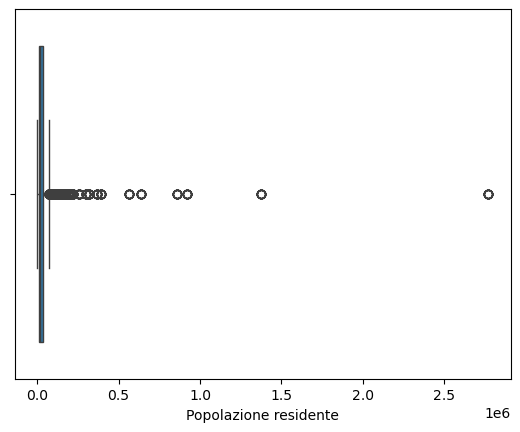

In [229]:
# Understanding if I can delete other municipalities

sns.boxplot(x = 'Popolazione residente', data = serious_car_accidents_per_comune_recent_years)

In [230]:
np.percentile(serious_car_accidents_per_comune_recent_years['Popolazione residente'], [25, 50, 75])

array([11914., 19250., 36421.])

Comments: 

- Boxplot and percentiles show that the majority of municipalities has a low number of habitants, therefore I cannot delet them. 

I came to the final database

----------------

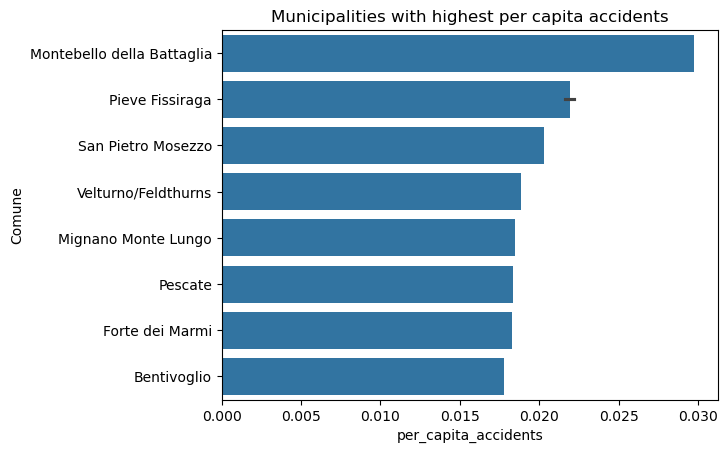

In [242]:
sns.barplot(x = 'per_capita_accidents', y= 'Comune', data = serious_car_accidents_per_comune_recent_years.sort_values(by = 'per_capita_accidents', ascending=False).head(10))
plt.title('Municipalities with highest per capita accidents')
plt.show()

In [247]:
# Creating a dataframe to summarize incidents acrosso 2019 and 2024

summary = (serious_car_accidents_per_comune_recent_years.groupby(['Comune', 'Popolazione residente', 'Codice Regione', 'population_density', 'RESULT', 'Capoluogo di Provincia/Uts', 'Capoluogo di Regione'])
           .agg(
               total_obs = ('OBS_VALUE', 'sum'), 
               mean_per_capita_accidents = ('per_capita_accidents', 'mean'),
               max_per_capita_accidents = ('per_capita_accidents', 'max'),
               mean_per_area_accidents = ('per_area_accidents', 'mean'),
               max_per_area_accidents = ('per_area_accidents', 'max')
               )
               .reset_index()
)   

In [248]:
summary.sort_values(by = 'mean_per_capita_accidents', ascending=False).head(20)

,Comune,Popolazione residente,Codice Regione,population_density,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,total_obs,mean_per_capita_accidents,max_per_capita_accidents,mean_per_area_accidents,max_per_area_accidents
1631,Montebello della Battaglia,1512.0,3,96.051227,F,0,0,45,0.029762,0.029762,2.858667,2.858667
1967,Pieve Fissiraga,1711.0,3,139.499238,F,0,0,75,0.021917,0.022209,3.057406,3.098171
2380,San Pietro Mosezzo,2019.0,1,57.852329,F,0,0,41,0.020307,0.020307,1.174812,1.174812
2886,Velturno/Feldthurns,3025.0,4,123.045509,F,0,0,57,0.018843,0.018843,2.318543,2.318543
1547,Mignano Monte Lungo,2981.0,15,56.144435,F,0,0,55,0.018450,0.018450,1.035875,1.035875
1933,Pescate,2182.0,3,1038.998143,F,0,0,112,0.017110,0.018332,17.776931,19.046712
2662,Spotorno,3565.0,7,444.524801,F,0,0,60,0.016830,0.016830,7.481483,7.481483
210,Baragiano,2536.0,17,85.666993,F,0,0,42,0.016562,0.016562,1.418775,1.418775
1079,Forte dei Marmi,7217.0,9,785.549460,F,0,0,714,0.016489,0.018290,12.952804,14.367816
448,Campo di Trens/Freienfeld,2718.0,4,28.494927,F,0,0,44,0.016188,0.016188,0.461287,0.461287


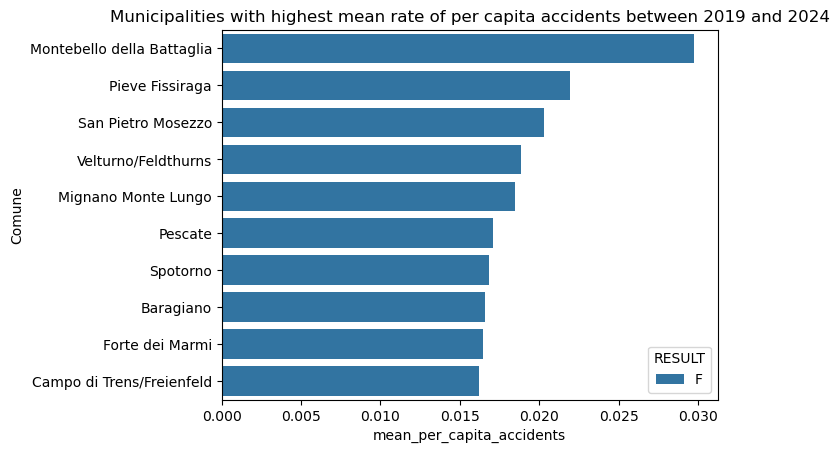

In [256]:
sns.barplot(x = 'mean_per_capita_accidents', y = 'Comune', hue = 'RESULT', data = summary.sort_values(by = 'mean_per_capita_accidents', ascending=False).head(10))
plt.title('Municipalities with highest mean rate of per capita accidents between 2019 and 2024')
plt.show()

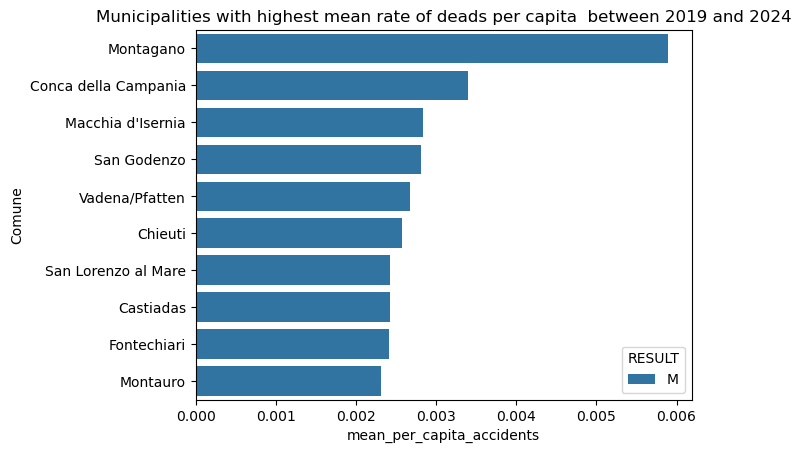

In [257]:
sns.barplot(x = 'mean_per_capita_accidents', y = 'Comune', hue = 'RESULT', data = summary[summary['RESULT']== 'M'].sort_values(by = 'mean_per_capita_accidents', ascending=False).head(10))
plt.title('Municipalities with highest mean rate of deads per capita  between 2019 and 2024')
plt.show()

<Axes: xlabel='Popolazione residente', ylabel='mean_per_capita_accidents'>

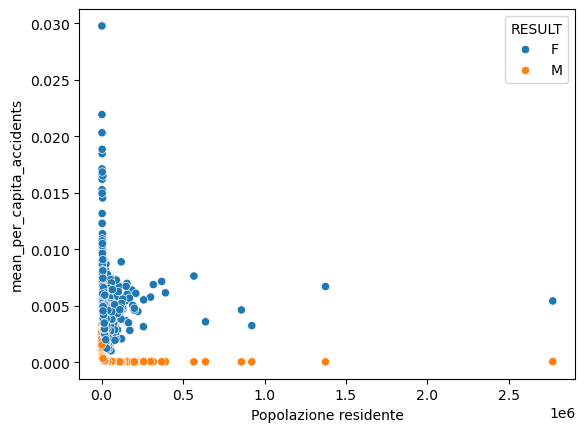

In [255]:
sns.scatterplot(x = 'Popolazione residente', y = 'mean_per_capita_accidents', hue = 'RESULT', data = summary)

The concentration of per capita accidents is higher in municipalities with a lower number of population

In [258]:
summary[summary['Capoluogo di Regione'] == 1.0].sort_values(by = 'mean_per_capita_accidents', ascending=False).head(20)

,Comune,Popolazione residente,Codice Regione,population_density,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,total_obs,mean_per_capita_accidents,max_per_capita_accidents,mean_per_area_accidents,max_per_area_accidents
1142,Genova,566410.0,7,2357.216935,F,1,1,25913,0.007625,0.008390,17.973601,19.776301
1028,Firenze,368419.0,9,3600.809652,F,1,1,15798,0.007147,0.008205,25.734101,29.545837
226,Bari,317205.0,16,2701.693301,F,1,1,13075,0.006870,0.007970,18.560363,21.531441
1549,Milano,1374582.0,3,7566.021919,F,1,1,55223,0.006696,0.007815,50.660059,59.131993
294,Bologna,391686.0,8,2780.742968,F,1,1,14434,0.006142,0.006972,17.078835,19.388513
92,Ancona,99273.0,11,795.021635,F,1,1,3383,0.005680,0.006235,4.515424,4.957223
2217,Roma,2770226.0,12,2151.846444,F,1,1,90070,0.005419,0.006207,11.660710,13.357449
2815,Trieste,200609.0,6,2357.224522,F,1,1,5751,0.004778,0.005169,11.262704,12.185106
2756,Torino,858205.0,1,6598.303150,F,1,1,23814,0.004625,0.005063,30.515629,33.406502
2796,Trento,118879.0,4,752.995412,F,1,1,2718,0.003811,0.004803,2.869362,3.616790


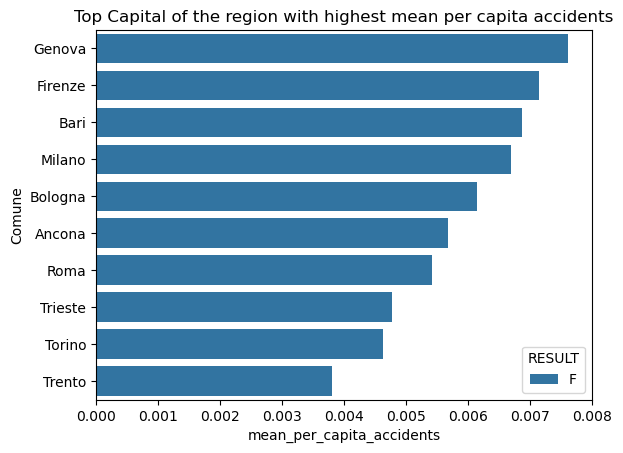

In [ ]:
sns.barplot(x = 'mean_per_capita_accidents', y = 'Comune', hue = 'RESULT', data = summary[summary['Capoluogo di Regione'] == 1.0].sort_values(by = 'mean_per_capita_accidents', ascending=False).head(10))
plt.title('Top Capital of the region with highest mean per capita accidents between 2019 and 2024')
plt.show()

Text(0.5, 1.0, 'Capital of the region with highest per capita accidents in 2024')

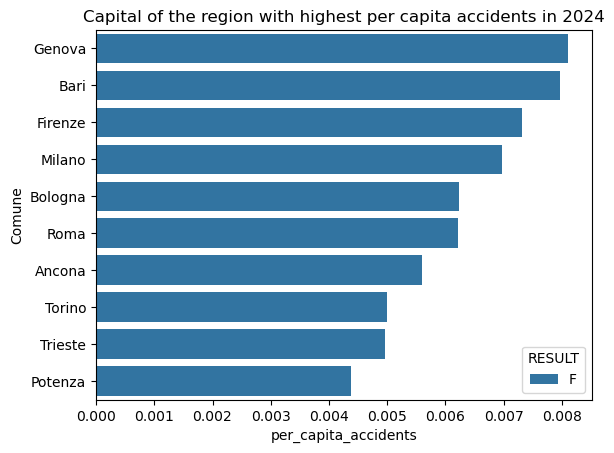

In [266]:
sns.barplot(x = 'per_capita_accidents', y = 'Comune', hue = 'RESULT', data = serious_car_accidents_per_comune_recent_years[
    (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) & 
    (serious_car_accidents_per_comune_recent_years['Capoluogo di Regione'] == 1.0)].sort_values(by = 'per_capita_accidents', ascending = False).head(10))
plt.title('Capital of the region with highest per capita accidents in 2024')

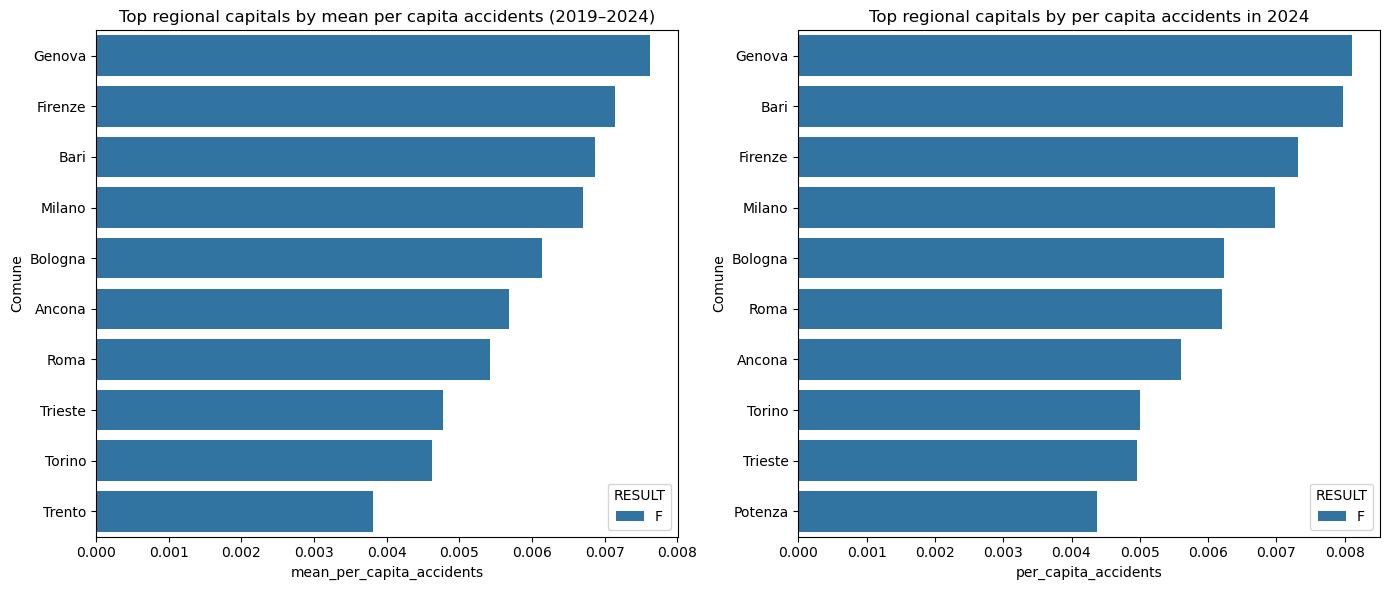

In [265]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 riga, 2 colonne

# 1) Media 2019–2024
sns.barplot(
    x='mean_per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=summary[summary['Capoluogo di Regione'] == 1.0]
         .sort_values(by='mean_per_capita_accidents', ascending=False)
         .head(10),
    ax=axes[0]
)
axes[0].set_title('Top regional capitals by mean per capita accidents (2019–2024)')

# 2) Solo 2024
sns.barplot(
    x='per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=serious_car_accidents_per_comune_recent_years[
        (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) &
        (serious_car_accidents_per_comune_recent_years['Capoluogo di Regione'] == 1.0)
    ].sort_values(by='per_capita_accidents', ascending=False)
     .head(10),
    ax=axes[1]
)
axes[1].set_title('Top regional capitals by per capita accidents in 2024')

plt.tight_layout()
plt.show()

In [166]:
summary[summary['Capoluogo di Provincia/Uts'] == 1.0].sort_values(by = 'mean_per_capita', ascending=False).head(20)

,Comune,Popolazione residente,Codice Regione,population_density,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,total_obs,mean_per_capita,max_per_capita
261,Bergamo,119993.0,3.0,2988.506033,F,1.0,0.0,6396,0.008884,0.010151
1142,Genova,566410.0,7.0,2357.216935,F,1.0,1.0,25913,0.007625,0.008390
1482,Massa,66977.0,9.0,713.738428,F,1.0,0.0,2953,0.007348,0.008839
1989,Pisa,89969.0,9.0,486.137603,F,1.0,0.0,3927,0.007275,0.007958
1028,Firenze,368419.0,9.0,3600.809652,F,1.0,1.0,15798,0.007147,0.008205
2520,Savona,58949.0,7.0,902.500712,F,1.0,0.0,2483,0.007020,0.008346
1358,Livorno,155370.0,9.0,1483.758588,F,1.0,0.0,6508,0.006981,0.007897
226,Bari,317205.0,16.0,2701.693301,F,1.0,1.0,13075,0.006870,0.007970
2183,Rimini,150240.0,8.0,1106.402094,F,1.0,0.0,6053,0.006715,0.007748
301,Bolzano/Bozen,107467.0,4.0,2055.172018,F,1.0,0.0,4320,0.006700,0.007872


In [170]:
serious_car_accidents_per_comune_recent_years[
    (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) & 
    (serious_car_accidents_per_comune_recent_years['Capoluogo di Provincia/Uts'] == 1.0)].sort_values(by = 'per_capita_accidents', ascending = False).head(20)

,index,Comune,TIME_PERIOD,Popolazione residente,Superficie (Kmq),Codice Regione,RESULT,Capoluogo di Provincia/Uts,Capoluogo di Regione,OBS_VALUE,per_capita_accidents,per_area_accidents,population_density
873,15631,Bergamo,2024,119993.0,40.1515,3.0,F,1.0,0.0,1078,0.008984,26.848312,2988.506033
7772,155706,Savona,2024,58949.0,65.3174,7.0,F,1.0,0.0,492,0.008346,7.532449,902.500712
3606,72448,Genova,2024,566410.0,240.2876,7.0,F,1.0,1.0,4594,0.008111,19.118756,2357.216935
743,13101,Bari,2024,317205.0,117.4097,16.0,F,1.0,1.0,2528,0.007970,21.531441,2701.693301
6230,122858,Pisa,2024,89969.0,185.0690,9.0,F,1.0,0.0,716,0.007958,3.868827,486.137603
4280,84529,Livorno,2024,155370.0,104.7138,9.0,F,1.0,0.0,1227,0.007897,11.717653,1483.758588
987,18151,Bolzano/Bozen,2024,107467.0,52.2910,4.0,F,1.0,0.0,846,0.007872,16.178692,2055.172018
4664,92137,Massa,2024,66977.0,93.8397,9.0,F,1.0,0.0,513,0.007659,5.466769,713.738428
3249,65616,Firenze,2024,368419.0,102.3156,9.0,F,1.0,1.0,2697,0.007320,26.359617,3600.809652
8313,166513,Taranto,2024,190717.0,249.8582,16.0,F,1.0,0.0,1339,0.007021,5.359040,763.300944


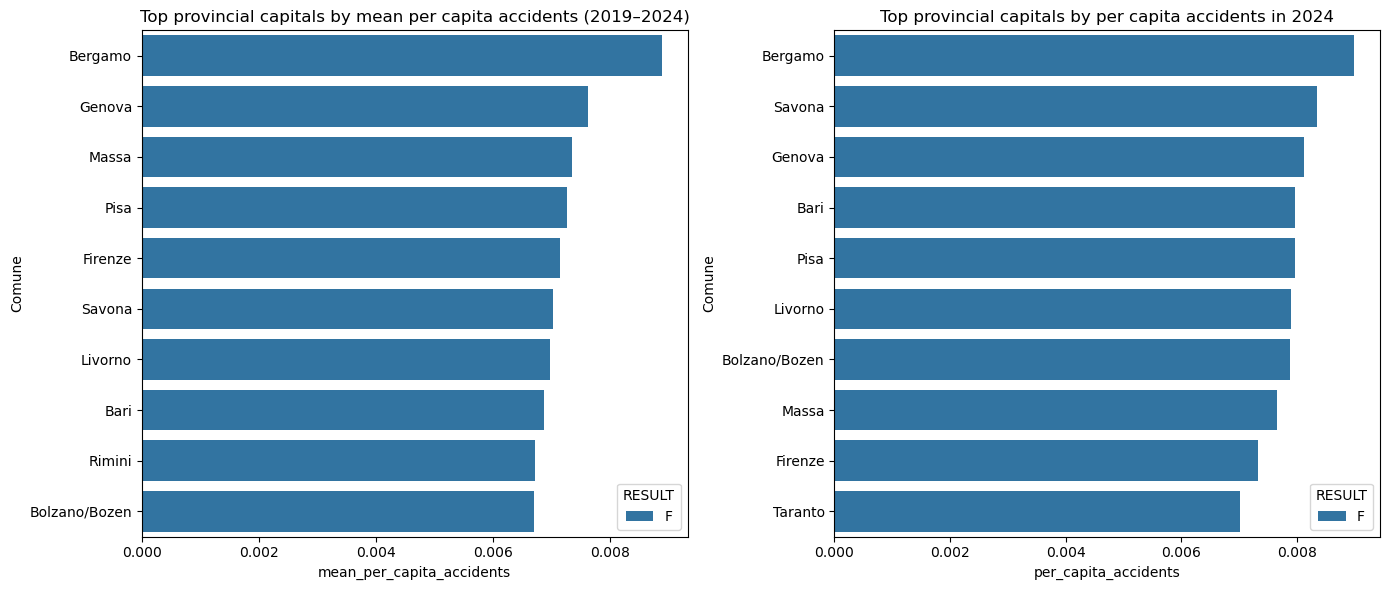

In [267]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 riga, 2 colonne

# 1) Media 2019–2024
sns.barplot(
    x='mean_per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=summary[summary['Capoluogo di Provincia/Uts'] == 1.0]
         .sort_values(by='mean_per_capita_accidents', ascending=False)
         .head(10),
    ax=axes[0]
)
axes[0].set_title('Top provincial capitals by mean per capita accidents (2019–2024)')

# 2) Solo 2024
sns.barplot(
    x='per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=serious_car_accidents_per_comune_recent_years[
        (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) &
        (serious_car_accidents_per_comune_recent_years['Capoluogo di Provincia/Uts'] == 1.0)
    ].sort_values(by='per_capita_accidents', ascending=False)
     .head(10),
    ax=axes[1]
)
axes[1].set_title('Top provincial capitals by per capita accidents in 2024')

plt.tight_layout()
plt.show()

-----

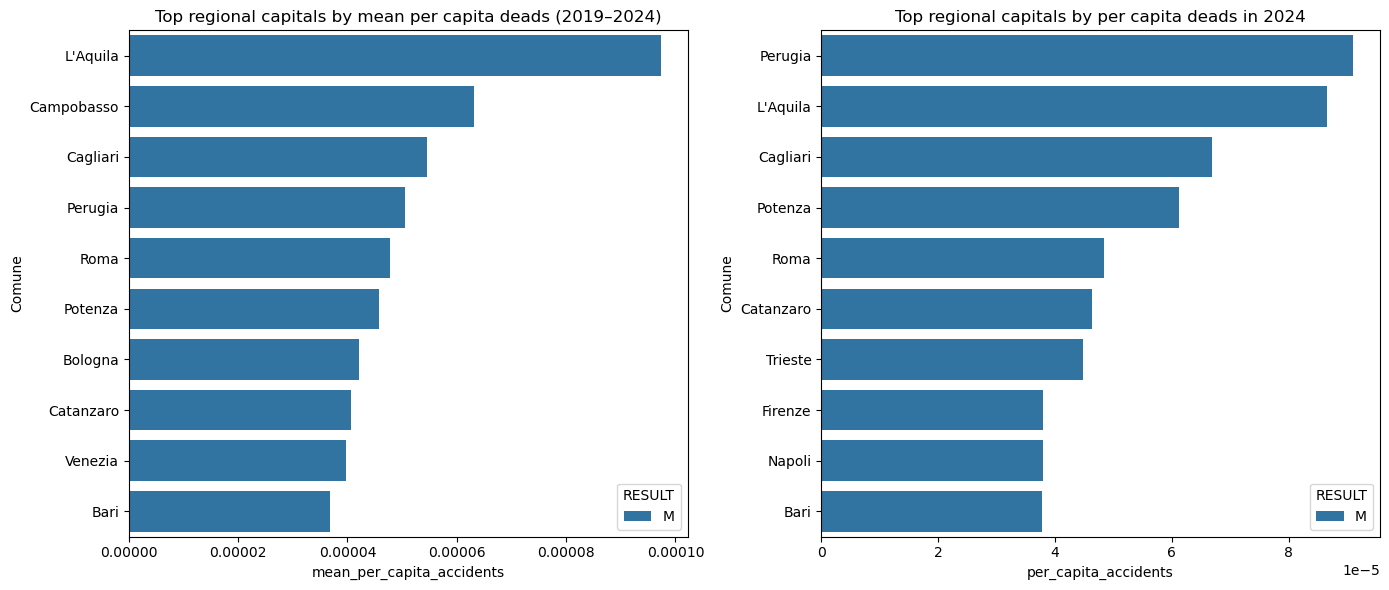

In [268]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 riga, 2 colonne

# 1) Media 2019–2024
sns.barplot(
    x='mean_per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=summary[(summary['Capoluogo di Regione'] == 1.0) & (summary['RESULT'] == 'M')]
         .sort_values(by='mean_per_capita_accidents', ascending=False)
         .head(10),
    ax=axes[0]
)
axes[0].set_title('Top regional capitals by mean per capita deads (2019–2024)')

# 2) Solo 2024
sns.barplot(
    x='per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=serious_car_accidents_per_comune_recent_years[
        (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) &
        (serious_car_accidents_per_comune_recent_years['Capoluogo di Regione'] == 1.0) &
        (serious_car_accidents_per_comune_recent_years['RESULT'] == 'M')
    ].sort_values(by='per_capita_accidents', ascending=False)
     .head(10),
    ax=axes[1]
)
axes[1].set_title('Top regional capitals by per capita deads in 2024')

plt.tight_layout()
plt.show()

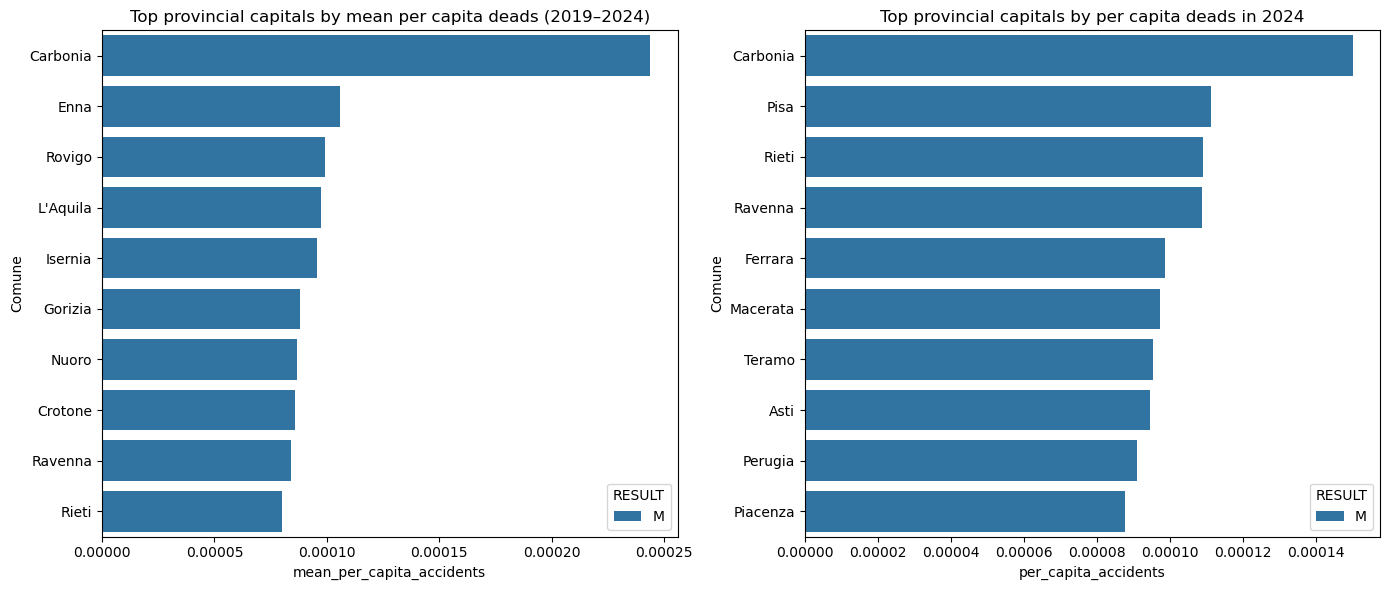

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 riga, 2 colonne

# 1) Media 2019–2024
sns.barplot(
    x='mean_per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=summary[(summary['Capoluogo di Provincia/Uts'] == 1.0) & (summary['RESULT'] == 'M')]
         .sort_values(by='mean_per_capita_accidents', ascending=False)
         .head(10),
    ax=axes[0]
)
axes[0].set_title('Top provincial capitals by mean per capita deads (2019–2024)')

# 2) Solo 2024
sns.barplot(
    x='per_capita_accidents',
    y='Comune',
    hue='RESULT',
    data=serious_car_accidents_per_comune_recent_years[
        (serious_car_accidents_per_comune_recent_years['TIME_PERIOD'] == 2024.0) &
        (serious_car_accidents_per_comune_recent_years['Capoluogo di Provincia/Uts'] == 1.0) &
        (serious_car_accidents_per_comune_recent_years['RESULT'] == 'M')
    ].sort_values(by='per_capita_accidents', ascending=False)
     .head(10),
    ax=axes[1]
)
axes[1].set_title('Top provincial capitals by per capita deads in 2024')

plt.tight_layout()
plt.show()

Comments onn the results: 

1 - In termini assoluti il fatto che Roma triplichi Milano (che è al secondo posto) per mortalità stradale è un dato che non può essere escluso anche se Roma non è la principale città per tasso di mortalità stradale per abitante (comunque al quinto posto considerando solo i capoluoghi).

2 -  In termini di tasso medio di incidenti per abitante tra il 2019 e il 2024 Montebello della battablia è il comune con il più alto rapporto.

3 - Montagano invece è il comune con il più alto tasso di mortalità stradale tra il 2019 e il 2024

4- Lo scatterplot tuttavia mostra come il rapporto di incidente per abitante è concentrato su comuni con basso numero di abitanti. Per questo nei successivi graffici vado a mostrare solamente i capoluoghi di regione e provincia.

5 - Genova è la città con il più alto rapporto di incidenti per abitante considerando solo i capoluoghi: il dato è confermato guardando anche solo all'ultimo anno disponibile ovvero il 2024

6 - Guardando invece ai capoluoghi di provincia Bergamo è la città con il più alto tasso di incidenti per abitante (dato confermato guardando anche al solo 2024). Interessante notare come in questi grafici ci sia una alta coneentrazione di città in Toscana e Liguria.

7 - Guardando al tasso di mortalità L'Aquila in media tra il 2019 e il 2024 è la città con la mortalità media più alta e Perugia guardando al solo 2024.

8 - Ampliando lo sguardo anche ai capoluoghi di provincia, Carbonia è la città con il tasso di mortalità più alto, sia in media tra il 2019 e il 2024 sia guardando al solo 2024. 

Next step statistical analysys

In [271]:
summary.to_csv('summary_accidents_2019_2024.csv')